# Objective
To build a convolutional Autoencoder (CAE) that compresses facial images into a lower dimensional latent representation and then reconstructs them with minimal loss of information

# Purpose

A convolutional autoencoder is an unsupervised deep learning model used for :
Image compression image reconstruction feature extraction dimensionality reduction
the encoder learns a compressed representation (latent space),while the decoder learns to reconstruct the original image from this compressed representation


In [ ]:
# Libraries
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import Input , BatchNormalization
from tensorflow.keras.models import Model

In [ ]:
# Loading dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
# create a smaller dataset
source_folder = os.path.join(path, 'img_align_celeba', 'img_align_celeba')
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
        )

print("Copied", len(images),"images")


Copied 5000 images


In [ ]:
# # Upload kaggle API
# from google.colab import files
# files.upload()

In [ ]:
# DATA PREPROCESSING
IMAGE_SIZE = (64,64)

BATCH_SIZE = 32

In [ ]:
datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

In [ ]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "input",
    subset = "validation"
)

Found 1000 images belonging to 1 classes.


In [ ]:
train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "input",
    subset = "training"
)



Found 4000 images belonging to 1 classes.


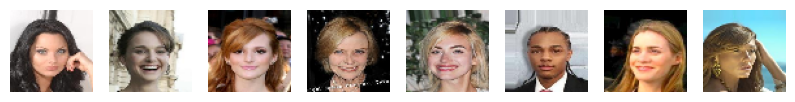

In [ ]:
images, _ = next(train_generator)
plt.figure(figsize=(10,5))

for i in range(8):
  plt.subplot(1,8, i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [ ]:
#build convutional autoencoder

# Encoder
input_img = Input(shape=(64,64,3))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

In [ ]:
#decoder
x= Conv2D(
    64,(3,3),
    activation='relu',
    padding='same'
    )(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(64,
           (3,3),
           activation='sigmoid',
           padding='same'
           )(x)

In [ ]:
# Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

In [ ]:
#create model
autoencoder = Model(
    input_img,
    decoded
)

In [ ]:
#compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
loss='mse'

In [ ]:
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_17 (UpSampling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_18 (UpSampling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_19 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 64, 64, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,203 (1.35 MB)

 Trainable params: 354,243 (1.35 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = autoencoder.fit(
    train_generator,
    epochs=60,
    validation_data=train_generator
)

Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - loss: 0.0200 - val_loss: 0.0518
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0115 - val_loss: 0.0289
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.0102 - val_loss: 0.0128
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0090 - val_loss: 0.0092
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.0084 - val_loss: 0.0072
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0078 - val_loss: 0.0072
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0077 - val_loss: 0.0070
Epoch 8/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0074 - val_loss: 0.0066
Epoch 9/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0067 - val_loss: 0.0060
Epoch 10/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.0067 - val_loss: 0.0069
Epoch 11/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.0067 - val_loss: 0.0060
Epoch 12/60
125/125 ━━━━━━━━━━━━━━━━━━━━